In [1]:
from google.colab import files
uploaded = files.upload()


Saving winequality-red.csv to winequality-red.csv


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

sns.set_style("whitegrid")

In [10]:
df = pd.read_csv("winequality-red.csv")
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (1599, 12)
Columns: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [5]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 1 columns):
 #   Column                                                                                                                                             Non-Null Count  Dtype 
---  ------                                                                                                                                             --------------  ----- 
 0   fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality  1599 non-null   object
dtypes: object(1)
memory usage: 12.6+ KB


,0
"fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality",0


In [6]:
df.describe()

,"fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality"
count,1599
unique,1359
top,"7.5,0.51,0.02,1.7,0.084,13.0,31.0,0.9953799999..."
freq,4


/tmp/ipykernel_412/3763839470.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality", data=df, palette="viridis")


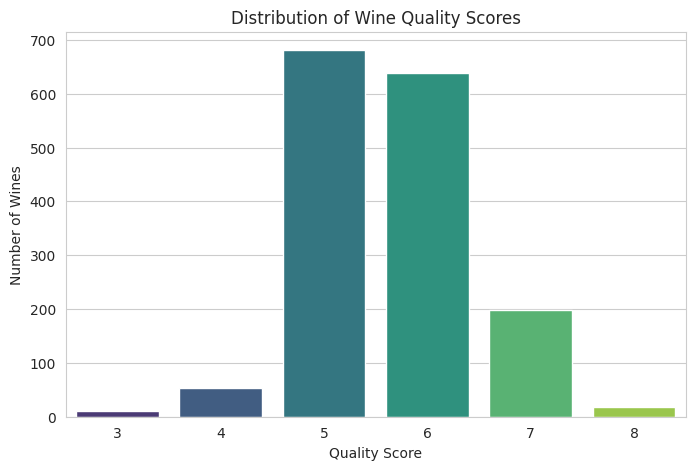

In [11]:
plt.figure(figsize=(8,5))
sns.countplot(x="quality", data=df, palette="viridis")
plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Quality Score")
plt.ylabel("Number of Wines")
plt.show()

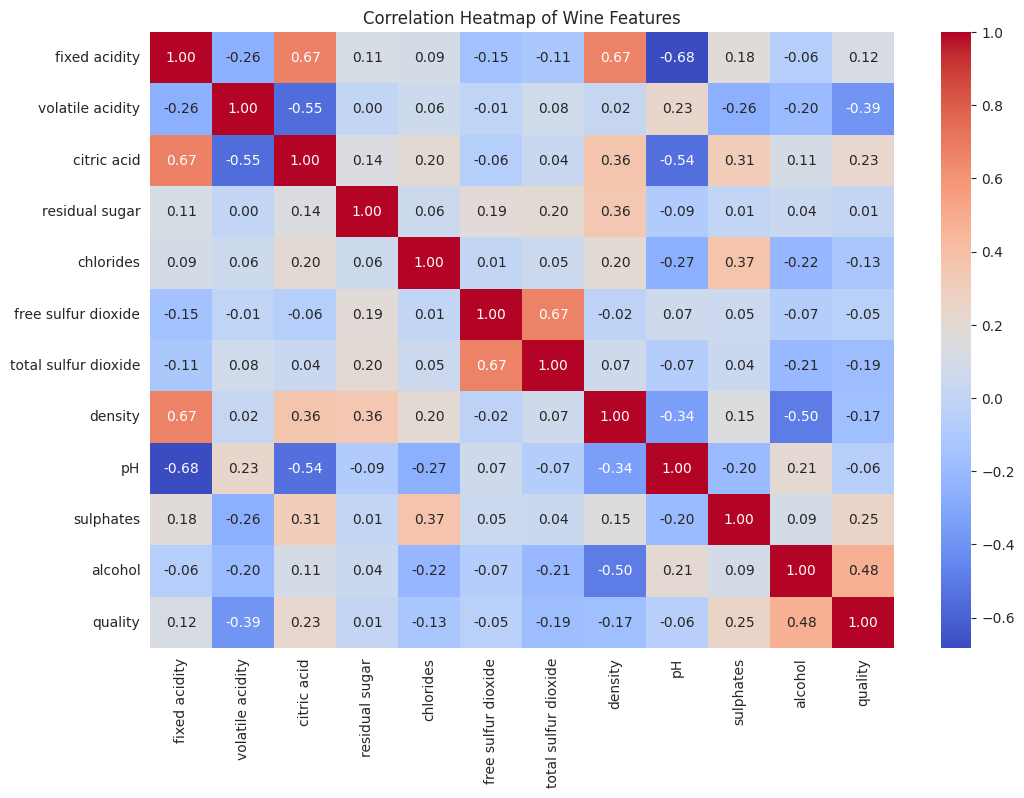

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap of Wine Features")
plt.show()

Quality label distribution:
quality_label
0    1382
1     217
Name: count, dtype: int64


/tmp/ipykernel_412/1335752670.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="quality_label", data=df, palette="Set2")


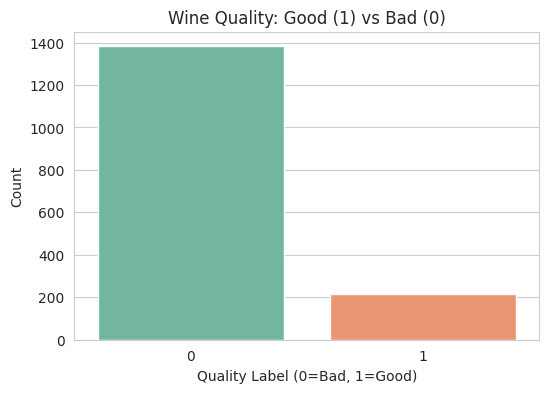

In [13]:
df["quality_label"] = df["quality"].apply(lambda x: 1 if x >= 7 else 0)

print("Quality label distribution:")
print(df["quality_label"].value_counts())

plt.figure(figsize=(6,4))
sns.countplot(x="quality_label", data=df, palette="Set2")
plt.title("Wine Quality: Good (1) vs Bad (0)")
plt.xlabel("Quality Label (0=Bad, 1=Good)")
plt.ylabel("Count")
plt.show()

In [14]:
X = df.drop(["quality", "quality_label"], axis=1)
y = df["quality_label"]

# Scale features so all columns are on the same numeric scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1279, 11)
Testing set size: (320, 11)


In [15]:
# Define all three models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SGD Classifier": SGDClassifier(random_state=42, max_iter=1000),
    "Support Vector Classifier": SVC(kernel="rbf", random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name}: Accuracy = {round(acc*100, 2)}%")

Random Forest: Accuracy = 90.0%
SGD Classifier: Accuracy = 85.31%
Support Vector Classifier: Accuracy = 87.5%


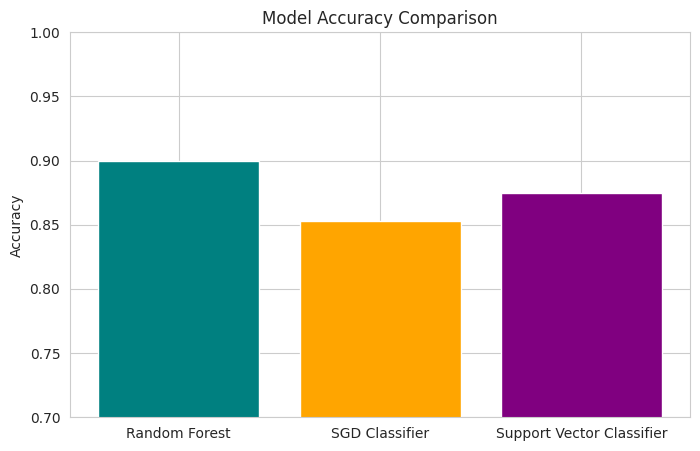

In [16]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values(), color=["teal", "orange", "purple"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0.7, 1.0)
plt.show()

In [17]:
# Retrain Random Forest and get detailed metrics
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Classification Report - Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=["Not Good", "Good"]))

Classification Report - Random Forest:
              precision    recall  f1-score   support

    Not Good       0.92      0.97      0.94       273
        Good       0.73      0.51      0.60        47

    accuracy                           0.90       320
   macro avg       0.82      0.74      0.77       320
weighted avg       0.89      0.90      0.89       320



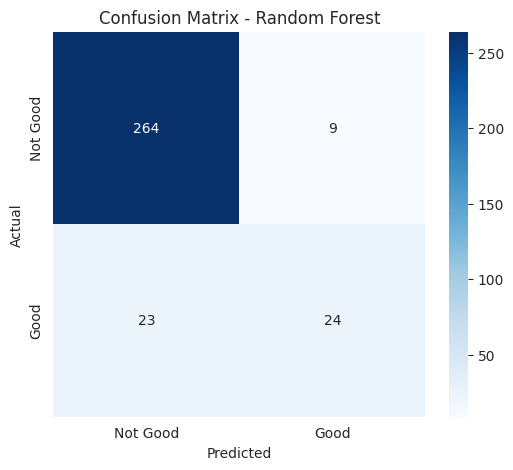

In [18]:
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Good", "Good"],
            yticklabels=["Not Good", "Good"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

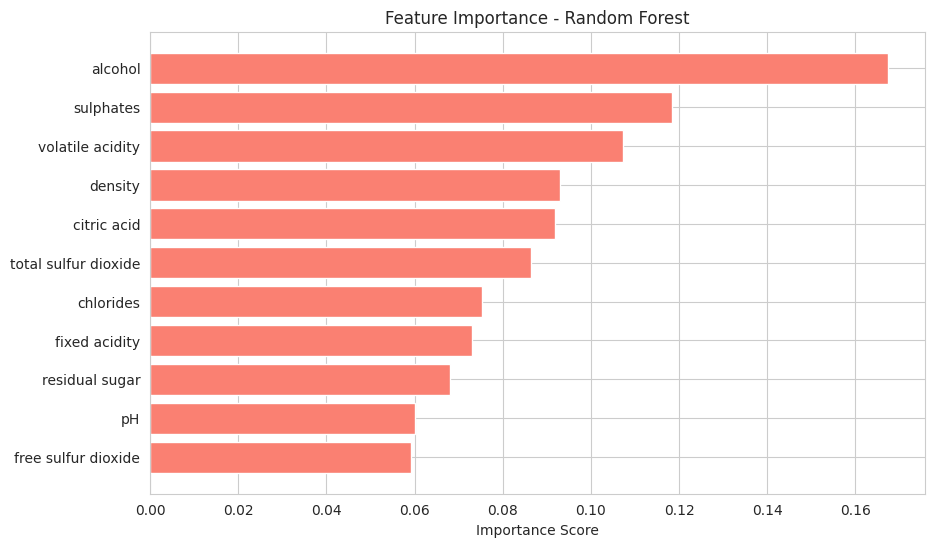

In [19]:
feature_names = df.drop(["quality", "quality_label"], axis=1).columns
importances = rf_model.feature_importances_

plt.figure(figsize=(10,6))
sorted_idx = np.argsort(importances)
plt.barh(feature_names[sorted_idx], importances[sorted_idx], color="salmon")
plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

## Insights and Recommendations

1. The dataset contains 1,599 red wine samples with 11 chemical features. No missing values were found, so no data cleaning was required.

2. Most wines in the dataset are rated 5 or 6 out of 10 — very few wines score 3 or 8, making the quality distribution naturally imbalanced.

3. Wine quality was converted into a binary classification problem: "Good" (quality ≥ 7) vs "Not Good" (quality < 7), which made model training more straightforward.

4. Three classifier models were trained and compared:
   - Random Forest: 90.0%
   - SGD Classifier: 85.31%
   - Support Vector Classifier: 87.5%
5. Random Forest performed the best overall, making it the recommended model for this task.

6. The most important features for predicting wine quality were alcohol content and sulphates, followed by volatile acidity. Higher alcohol and sulphate levels generally indicate better quality wine.

7. To improve results further, techniques like oversampling (SMOTE) could be used to handle the class imbalance between Good and Not Good wines.